In [7]:
import pyspedas
import cdflib
import pandas as pd
import numpy as np

print("--- A iniciar a extração híbrida no Google Colab ---")

# 2. O Download Inteligente: Pedimos ao PySpedas para APENAS DESCARREGAR o ficheiro
# Isto impede que o pytplot tente ler o ficheiro e quebre o processo.
arquivos_baixados = pyspedas.omni.data(trange=['2024-05-09', '2024-05-15'], datatype='1min', downloadonly=True)

if arquivos_baixados:
    # O PySpedas devolve uma lista com o caminho do ficheiro no disco
    caminho_do_arquivo = arquivos_baixados[0]
    print(f"\nSucesso! Ficheiro localizado em: {caminho_do_arquivo}")
    
    # 3. Leitura Bruta e Dinâmica: Abrir o ficheiro CDF
    print("A analisar o ficheiro e a extrair TODAS as variáveis disponíveis...")
    arquivo_cdf = cdflib.CDF(caminho_do_arquivo)
    
    # Extrair os tempos primeiro
    tempos_brutos = arquivo_cdf.varget('Epoch')
    tempos_datetime = pd.to_datetime(cdflib.cdfepoch.unixtime(tempos_brutos), unit='s')
    
    # Iniciar o dicionário da tabela com a coluna principal de Tempo
    dicionario_dados = {'Tempo': tempos_datetime}
    
    # 4. Obter a lista de todas as variáveis dentro do ficheiro
    info_cdf = arquivo_cdf.cdf_info()
    todas_variaveis = info_cdf.zVariables
    
    # 5. Laço de Repetição: Percorrer e extrair cada variável automaticamente
    for nome_var in todas_variaveis:
        if nome_var != 'Epoch': # Ignorar o tempo (já o extraímos)
            dados_var = arquivo_cdf.varget(nome_var)
            
            # Garantir que a variável tem o mesmo tamanho do tempo e é 1D (para caber na tabela)
            if isinstance(dados_var, np.ndarray) and len(dados_var) == len(tempos_brutos):
                if dados_var.ndim == 1: 
                    dicionario_dados[nome_var] = dados_var
    
    # 6. Construir a "Super Tabela" com todos os parâmetros
    df = pd.DataFrame(dicionario_dados)
    
    print("\n--- ANTES DA LIMPEZA (Com erros do satélite) ---")
    print(df[['Tempo', 'BZ_GSE', 'flow_speed', 'T']].head())
    
    # 7. A Navalha Física: Limpeza dos "Fill Values" (Tratamento de Dados)
    print("\nA aplicar limites físicos para limpar os dados corrompidos...")
    
    # 7.1 Limpar o Campo Magnético (Valores reais raramente passam de 100 nT)
    colunas_mag = ['F', 'BX_GSE', 'BY_GSE', 'BZ_GSE', 'BY_GSM', 'BZ_GSM']
    for col in colunas_mag:
        if col in df.columns:
            # Mantém o dado APENAS se o valor absoluto for menor que 1000 nT
            df[col] = df[col].where(df[col].abs() < 1000, np.nan)

    # 7.2 Limpar a Velocidade do Vento Solar (Valores reais não passam de ~3000 km/s)
    colunas_vel = ['flow_speed', 'Vx', 'Vy', 'Vz']
    for col in colunas_vel:
        if col in df.columns:
            df[col] = df[col].where(df[col].abs() < 5000, np.nan)
            
    # 7.3 Limpar Densidade e Temperatura
    if 'proton_density' in df.columns:
        df['proton_density'] = df['proton_density'].where(df['proton_density'] < 1000, np.nan)
    if 'T' in df.columns:
        # A temperatura de preenchimento é 9999999.0, valores reais são menores que 8 milhões
        df['T'] = df['T'].where(df['T'] < 8000000, np.nan)
        
    print("\n--- DEPOIS DA LIMPEZA (Física Pura) ---")
    print(df[['Tempo', 'BZ_GSE', 'flow_speed', 'T']].head())
    
    print(f"\n--- SUCESSO! TABELA COMPLETA COM {len(df.columns)} COLUNAS ---")
    
    # Pedir ao Pandas para não esconder colunas ao imprimir
    pd.set_option('display.max_columns', None) 
    print(df.head())
    
else:
    print("\nFalha: Nenhum ficheiro foi descarregado. Verifique a sua ligação à internet.")

--- A iniciar a extração híbrida no Google Colab ---

Sucesso! Ficheiro localizado em: omni_data/hro_1min/2024/omni_hro_1min_20240501_v01.cdf
A analisar o ficheiro e a extrair TODAS as variáveis disponíveis...

--- ANTES DA LIMPEZA (Com erros do satélite) ---
                Tempo  BZ_GSE  flow_speed          T
0 2024-05-01 00:00:00 9999.99    99999.90 9999999.00
1 2024-05-01 00:01:00 9999.99    99999.90 9999999.00
2 2024-05-01 00:02:00   -9.36    99999.90 9999999.00
3 2024-05-01 00:03:00   -8.98      415.80   24784.00
4 2024-05-01 00:04:00   -8.92      415.70   25085.00

A aplicar limites físicos para limpar os dados corrompidos...

--- DEPOIS DA LIMPEZA (Física Pura) ---
                Tempo  BZ_GSE  flow_speed        T
0 2024-05-01 00:00:00     NaN         NaN      NaN
1 2024-05-01 00:01:00     NaN         NaN      NaN
2 2024-05-01 00:02:00   -9.36         NaN      NaN
3 2024-05-01 00:03:00   -8.98      415.80 24784.00
4 2024-05-01 00:04:00   -8.92      415.70 25085.00

--- SUCESSO

In [8]:
import pyspedas
import cdflib
import pandas as pd
import numpy as np
import warnings
import os
import time
import logging
from datetime import datetime

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

ano_atual = datetime.now().year
arquivo_cache = "omni_dados.pkl"

print(f"--- INICIANDO PROCESSAMENTO (Desde 1981 até {ano_atual}) ---")

df_cache = None
ano_inicio_download = 1981

if os.path.exists(arquivo_cache):
    print("A carregar cache histórico do disco...")
    df_cache = pd.read_pickle(arquivo_cache)
    ultimo_ano_cache = df_cache['Tempo'].dt.year.max()
    
    if ultimo_ano_cache == ano_atual:
        print(f"O cache contém dados de {ano_atual}. A verificar atualizações dos últimos dias na NASA...")
        ano_inicio_download = ano_atual
    else:
        print(f"Cache desatualizado (último ano: {ultimo_ano_cache}). A retomar o download...")
        ano_inicio_download = ultimo_ano_cache

arquivos_baixados = []

for ano in range(ano_inicio_download, ano_atual + 1):
    try:
        trange = [f'{ano}-01-01', f'{ano+1}-01-01']
        nao_atualizar = True if ano < ano_atual else False
        
        files = pyspedas.omni.data(trange=trange, datatype='1min', downloadonly=True, no_update=nao_atualizar)
        
        if files:
            for f in files:
                if f not in arquivos_baixados:
                    arquivos_baixados.append(f)
        time.sleep(2)
    except Exception as e:
        print(f"Aviso no ano {ano}: {e}")

if arquivos_baixados:
    lista_de_tabelas = []
    
    print("A processar novos ficheiros CDF...")
    for caminho_do_arquivo in arquivos_baixados:
        try:
            arquivo_cdf = cdflib.CDF(caminho_do_arquivo)
            
            tempos_brutos = arquivo_cdf.varget('Epoch')
            tempos_datetime = pd.to_datetime(cdflib.cdfepoch.unixtime(tempos_brutos), unit='s')
            dicionario_dados = {'Tempo': tempos_datetime}
            
            info_cdf = arquivo_cdf.cdf_info()
            for nome_var in info_cdf.zVariables:
                if nome_var != 'Epoch':
                    dados_var = arquivo_cdf.varget(nome_var)
                    if isinstance(dados_var, np.ndarray) and len(dados_var) == len(tempos_brutos) and dados_var.ndim == 1: 
                        dicionario_dados[nome_var] = dados_var
            
            lista_de_tabelas.append(pd.DataFrame(dicionario_dados))
        except:
            continue
            
    print("A fundir e limpar a base de dados...")
    df_novos = pd.concat(lista_de_tabelas, ignore_index=True)
    del lista_de_tabelas 
    
    if df_cache is not None:
        df = pd.concat([df_cache, df_novos], ignore_index=True)
        df.drop_duplicates(subset=['Tempo'], keep='last', inplace=True)
    else:
        df = df_novos
    
    colunas_mag = ['F', 'BX_GSE', 'BY_GSE', 'BZ_GSE', 'BY_GSM', 'BZ_GSM']
    for col in colunas_mag:
        if col in df.columns:
            df[col] = df[col].where(df[col].abs() < 1000, np.nan)

    colunas_vel = ['flow_speed', 'Vx', 'Vy', 'Vz']
    for col in colunas_vel:
        if col in df.columns:
            df[col] = df[col].where(df[col].abs() < 5000, np.nan)
            
    if 'proton_density' in df.columns:
        df['proton_density'] = df['proton_density'].where(df['proton_density'] < 1000, np.nan)
    if 'T' in df.columns:
        df['T'] = df['T'].where(df['T'] < 8000000, np.nan)
        
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    print(f"\n--- RESUMO ESTATÍSTICO GLOBAL (1981 - {ano_atual}) ---")
    print(df[['BZ_GSE', 'flow_speed', 'proton_density', 'AE_INDEX', 'SYM_H']].describe())
    
    df.to_pickle(arquivo_cache)
    print("\nCache guardado com sucesso! A sua base de dados está atualizada.")
else:
    print("Nenhum arquivo novo para processar.")

--- INICIANDO PROCESSAMENTO (Desde 1981 até 2026) ---
A carregar cache histórico do disco...
O cache contém dados de 2026. A verificar atualizações dos últimos dias na NASA...
A processar novos ficheiros CDF...
A fundir e limpar a base de dados...

--- RESUMO ESTATÍSTICO GLOBAL (1981 - 2026) ---
           BZ_GSE  flow_speed  proton_density    AE_INDEX       SYM_H
count 10491578.00  8786262.00     11317005.00 11317005.00 11317005.00
mean        -0.01      423.26          228.42      187.63       78.94
std          3.17       98.02          414.12     1616.59     2990.10
min        -61.72      180.70            0.06        1.00     -518.00
25%         -1.64      349.20            3.57       40.00      -17.00
50%          0.00      401.30            6.16       82.00       -8.00
75%          1.61      477.30           17.10      210.00       -1.00
max         63.61     1089.00          999.99    99999.00    99999.00

Cache guardado com sucesso! A sua base de dados está atualizada.


carregando os dados do cache...
Dados carregados com sucesso!

--- RELATÓRIO DE GAPS (2024-05-01 a 2024-05-15) ---
Total de minutos no período: 21600
Minutos com dados reais: 14061
Minutos perdidos (Gaps): 7539
Taxa de perda de dados: 34.90%


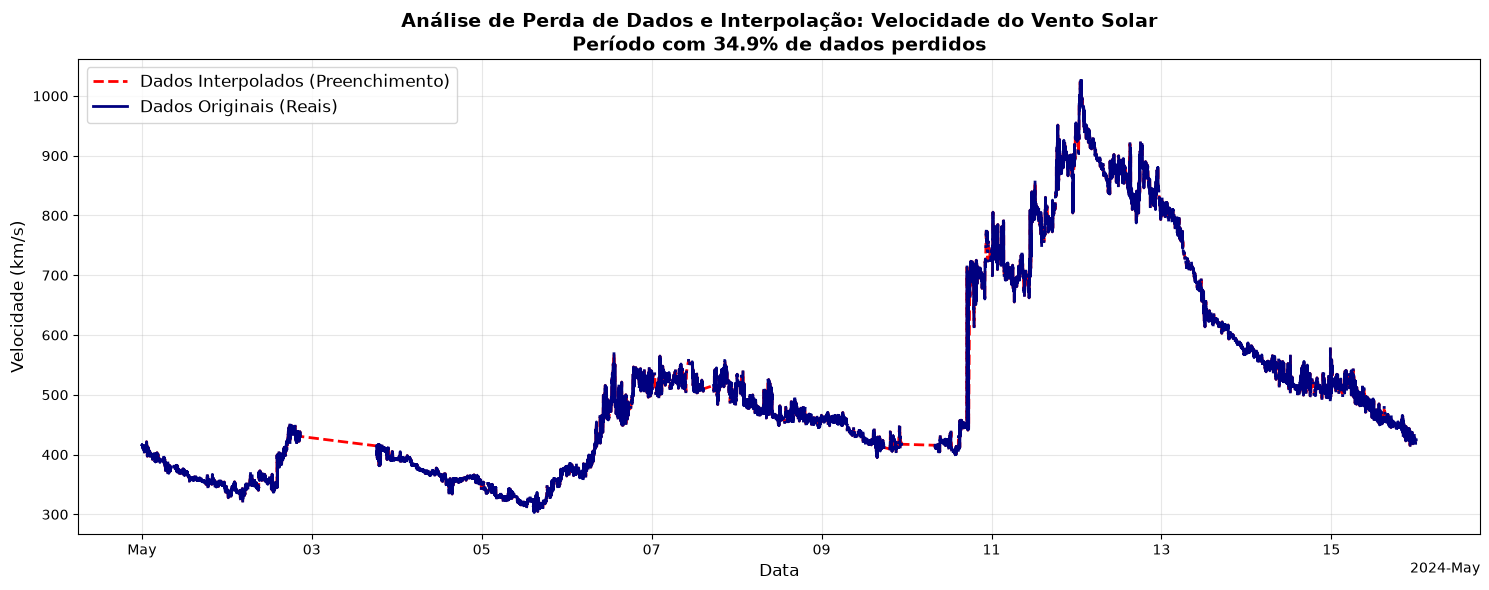

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("carregando os dados do cache...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    # Garantir que o Tempo é o índice (caso não tenha sido guardado assim)
    if 'Tempo' in df.columns:
        df.set_index('Tempo', inplace=True)
        
    print("Dados carregados com sucesso!")

    data_inicio = '2024-05-01'
    data_fim = '2024-05-15'
    componente = 'flow_speed' 
    
    df_zoom = df.loc[data_inicio:data_fim].copy()
    
    total_minutos = len(df_zoom)
    minutos_validos = df_zoom[componente].count()
    minutos_perdidos = total_minutos - minutos_validos
    percentagem_perda = (minutos_perdidos / total_minutos) * 100
    
    print(f"\n--- RELATÓRIO DE GAPS ({data_inicio} a {data_fim}) ---")
    print(f"Total de minutos no período: {total_minutos}")
    print(f"Minutos com dados reais: {minutos_validos}")
    print(f"Minutos perdidos (Gaps): {minutos_perdidos}")
    print(f"Taxa de perda de dados: {percentagem_perda:.2f}%")

    df_zoom['interpolado'] = df_zoom[componente].interpolate(method='time')
    
    plt.figure(figsize=(15, 6))
    

    plt.plot(df_zoom.index, df_zoom['interpolado'], 
             color='red', linestyle='--', linewidth=2, label='Dados Interpolados (Preenchimento)')
    

    plt.plot(df_zoom.index, df_zoom[componente], 
             color='navy', linewidth=2, label='Dados Originais (Reais)')
    
    plt.title(f'Análise de Perda de Dados e Interpolação: Velocidade do Vento Solar\nPeríodo com {percentagem_perda:.1f}% de dados perdidos', fontsize=14, fontweight='bold')
    plt.ylabel('Velocidade (km/s)', fontsize=12)
    plt.xlabel('Data', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado. Rode o script principal primeiro.")

Dados carregados com sucesso!

---> RESULTADO: Em 20 anos, o satélite falhou por exatos 1 MINUTO: 424,585 vezes!


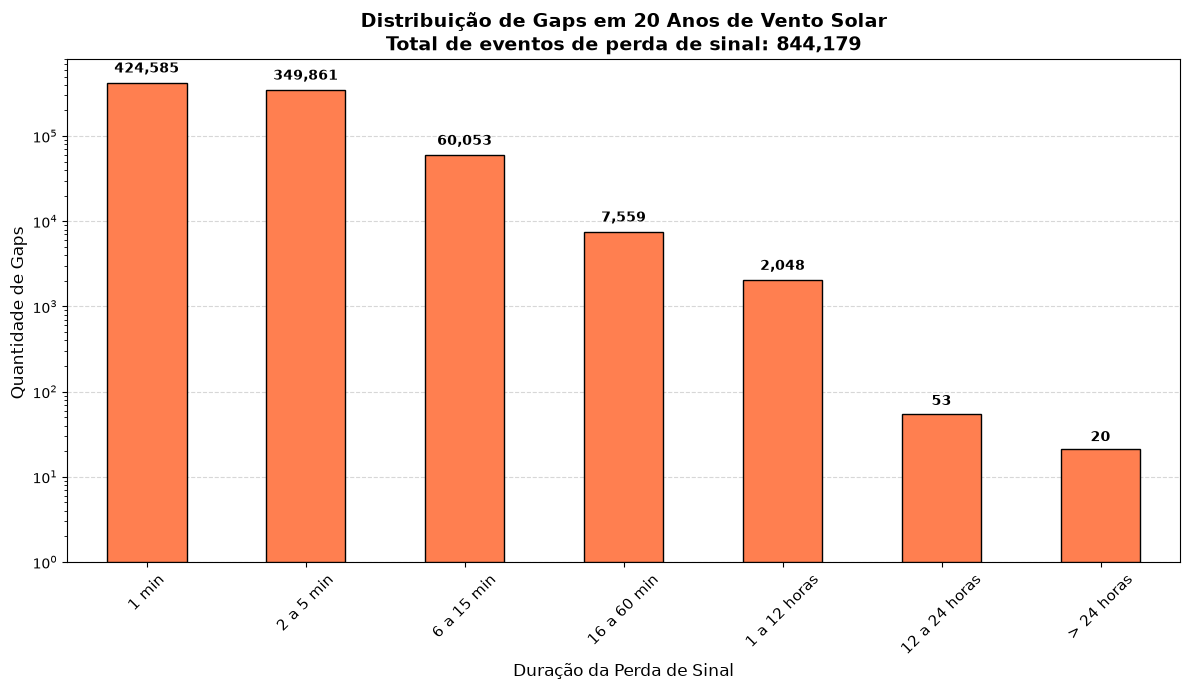

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    if 'Tempo' in df.columns:
        df.set_index('Tempo', inplace=True)
        
    print("Dados carregados com sucesso!")

    componente = 'flow_speed' 

    
    is_nan = df[componente].isna()
    
    
    blocks = (~is_nan).cumsum()
    
    
    tamanhos_gaps = blocks[is_nan].value_counts()
    

    gaps_1_min = (tamanhos_gaps == 1).sum()
    print(f"\n---> RESULTADO: Em 20 anos, o satélite falhou por exatos 1 MINUTO: {gaps_1_min:,} vezes!")

 
    bins = [1, 2, 6, 16, 61, 721, 1441, float('inf')]
    labels = ['1 min', '2 a 5 min', '6 a 15 min', '16 a 60 min', '1 a 12 horas', '12 a 24 horas', '> 24 horas']
    
    categorias_gaps = pd.cut(tamanhos_gaps, bins=bins, labels=labels, right=False)
    distribuicao = categorias_gaps.value_counts().reindex(labels)

    plt.figure(figsize=(12, 7))
    

    ax = distribuicao.plot(kind='bar', color='coral', edgecolor='black', zorder=3, log=True)
    
    for index, value in enumerate(distribuicao):
        plt.text(index, value * 1.2, f'{value:,}', ha='center', va='bottom', fontweight='bold', color='black')

    total_gaps = len(tamanhos_gaps)
    plt.title(f'Distribuição de Gaps em 20 Anos de Vento Solar\nTotal de eventos de perda de sinal: {total_gaps:,}', fontsize=14, fontweight='bold')
    plt.ylabel('Quantidade de Gaps ', fontsize=12)
    plt.xlabel('Duração da Perda de Sinal', fontsize=12)
    plt.xticks(rotation=45, fontsize=11)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado. Rode o script principal primeiro.")

Carregando dados...
Dados carregados com sucesso!

Procurando o maior tempo ininterrupto sem falhas)...

Maior peíodo sem gaps
Início exato : 10/11/2005 07:49:00
Fim exato    : 11/11/2005 14:22:00
Duração      : 1 dias e 6 horas contínuas!
Totalizações : 1,834 medições sem nenhum gap.

Gerando o gráfico deste período...


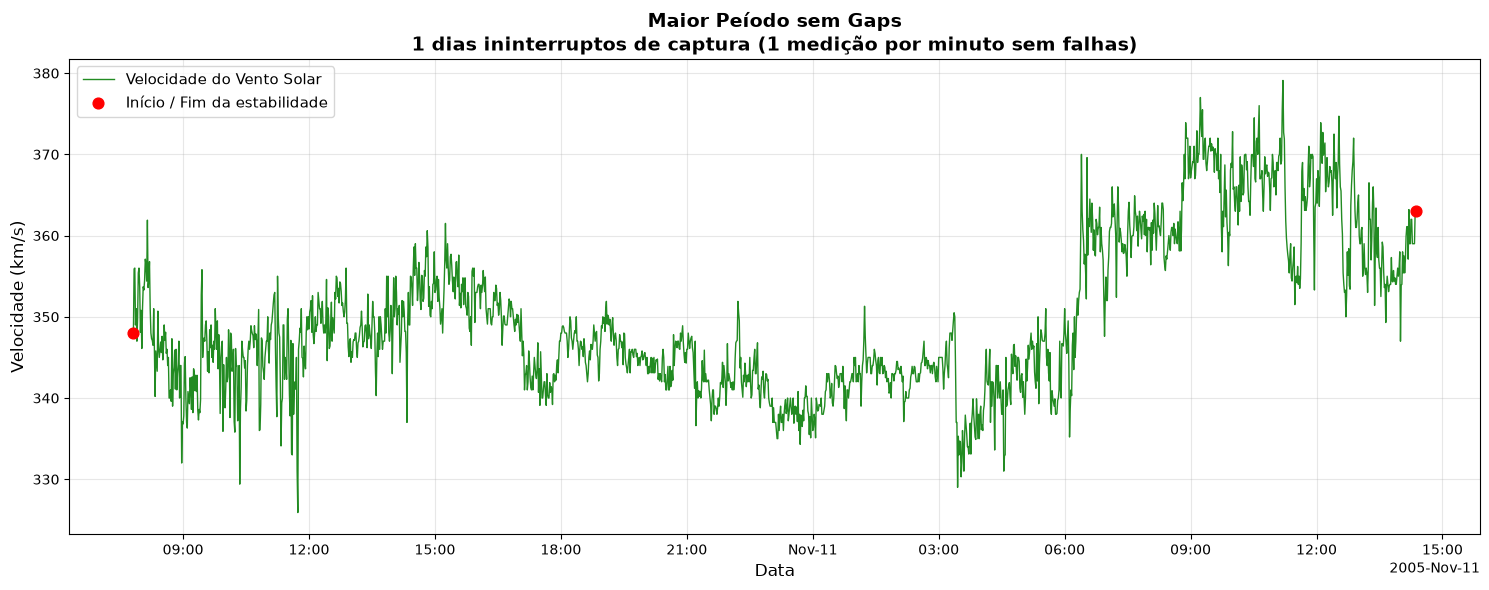

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Carregando dados...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    if 'Tempo' in df.columns:
        df.set_index('Tempo', inplace=True)
        
    print("Dados carregados com sucesso!")
    componente = 'flow_speed' 
    
    print("\nProcurando o maior tempo ininterrupto sem falhas...")
    
    tem_dado = df[componente].notna()
    
    blocos_continuos = (~tem_dado).cumsum()[tem_dado]
    
    tamanho_dos_blocos = blocos_continuos.value_counts()
    
    id_maior_bloco = tamanho_dos_blocos.idxmax()
    recorde_minutos = tamanho_dos_blocos.max()
    
    dados_perfeito = df[tem_dado][blocos_continuos == id_maior_bloco]
    data_inicio = dados_perfeito.index.min()
    data_fim = dados_perfeito.index.max()
    
    recorde_dias = recorde_minutos // (24 * 60)
    recorde_horas = (recorde_minutos % (24 * 60)) // 60
    
    print("\n" + "="*50)
    print("Maior peíodo sem gaps")
    print("="*50)
    print(f"Início exato : {data_inicio.strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"Fim exato    : {data_fim.strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"Duração      : {recorde_dias} dias e {recorde_horas} horas contínuas!")
    print(f"Totalizações : {recorde_minutos:,} medições sem nenhum gap.")
    print("="*50)

    print("\nGerando o gráfico deste período...")
    plt.figure(figsize=(15, 6))
    
    plt.plot(dados_perfeito.index, dados_perfeito[componente], 
             color='forestgreen', linewidth=1, label='Velocidade do Vento Solar')
    
    plt.title(f'Maior Peíodo sem Gaps\n{recorde_dias} dias ininterruptos de captura (1 medição por minuto sem falhas)', fontsize=14, fontweight='bold')
    plt.ylabel('Velocidade (km/s)', fontsize=12)
    plt.xlabel('Data', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.scatter([data_inicio, data_fim], 
                [dados_perfeito[componente].iloc[0], dados_perfeito[componente].iloc[-1]], 
                color='red', zorder=5, s=60, label='Início / Fim da estabilidade')
    
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado. Por favor, certifique-se de que a primeira célula (download) terminou com sucesso.")

A carregar a base de dados e a preparar o ambiente de simulação...

--- SIMULAÇÃO ESTATÍSTICA DE PERDA DE DADOS (GAPS FICTÍCIOS) ---
Alvo da simulação: Pico extremo de 1025.9 km/s registado em 12/05/2024 01:17
A apagar dados reais (simulando falha do satélite) e a calcular margem de erro...
Gap de   1 min -> Erro da Interpolação:  0.58%
Gap de   2 min -> Erro da Interpolação:  1.33%
Gap de   5 min -> Erro da Interpolação:  0.50%
Gap de  15 min -> Erro da Interpolação:  1.51%
Gap de  30 min -> Erro da Interpolação:  1.56%
Gap de  60 min -> Erro da Interpolação:  2.56%
Gap de 120 min -> Erro da Interpolação:  3.55%

A gerar a Curva de Degradação da Interpolação...


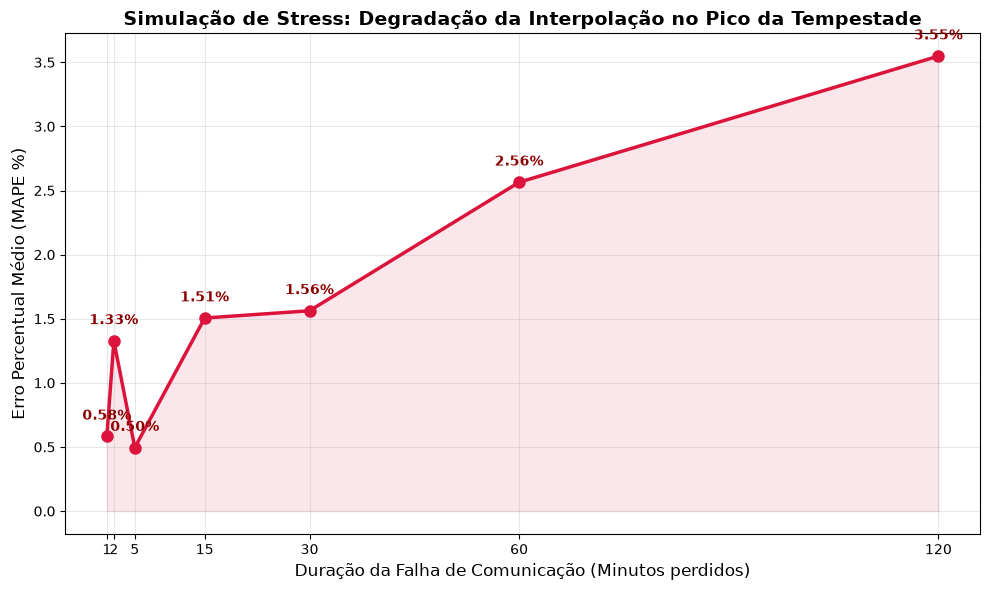

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

print("A carregar a base de dados e a preparar o ambiente de simulação...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    if 'Tempo' in df.columns:
        df.set_index('Tempo', inplace=True)
    
    componente = 'flow_speed'
    
    # EM VEZ DE PROCURAR O MAIOR PERÍODO, USAMOS UM EVENTO HISTÓRICO ISOLADO:
    # A Tempestade Solar G5 de Maio de 2024 (Extrema Volatilidade)
    print("\n--- SIMULAÇÃO ESTATÍSTICA DE PERDA DE DADOS (GAPS FICTÍCIOS) ---")
    data_inicio = '2024-05-10'
    data_fim = '2024-05-12'
    
    # Cortamos apenas os dados desse período crítico e removemos os NaNs reais para termos uma base limpa de teste
    df_evento = df.loc[data_inicio:data_fim, [componente]].dropna()
    
    idx_pico = df_evento[componente].argmax()
    ponto_pico = df_evento.index[idx_pico]
    valor_pico = df_evento[componente].iloc[idx_pico]
    
    print(f"Alvo da simulação: Pico extremo de {valor_pico:.1f} km/s registado em {ponto_pico.strftime('%d/%m/%Y %H:%M')}")
    
    tamanhos_teste = [1, 2, 5, 15, 30, 60, 120] 
    erros_percentuais = []
    
    print("A apagar dados reais (simulando falha do satélite) e a calcular margem de erro...")
    for tamanho in tamanhos_teste:
        df_sim = df_evento.copy()
        
        inicio_buraco = max(0, idx_pico - (tamanho // 2))
        fim_buraco = min(len(df_sim), inicio_buraco + tamanho)
        
        # Guardar a verdade incontestável antes de a destruir
        dados_reais = df_sim.iloc[inicio_buraco:fim_buraco][componente].copy()
        
        # Apagar os dados
        df_sim.iloc[inicio_buraco:fim_buraco, df_sim.columns.get_loc(componente)] = np.nan
        
        df_sim['interpolado'] = df_sim[componente].interpolate(method='time')
        dados_interpolados = df_sim.iloc[inicio_buraco:fim_buraco]['interpolado']
        
        # Calcular o erro absoluto (MAPE)
        erro_mape = (np.abs((dados_reais - dados_interpolados) / dados_reais).mean()) * 100
        erros_percentuais.append(erro_mape)
        
        print(f"Gap de {tamanho:3} min -> Erro da Interpolação: {erro_mape:5.2f}%")

    print("\nA gerar a Curva de Degradação da Interpolação...")
    
    plt.figure(figsize=(10, 6))
    plt.plot(tamanhos_teste, erros_percentuais, color='crimson', marker='o', linewidth=2.5, markersize=8)
    plt.fill_between(tamanhos_teste, erros_percentuais, color='crimson', alpha=0.1)
    
    for i, txt in enumerate(erros_percentuais):
        plt.annotate(f"{txt:.2f}%", (tamanhos_teste[i], erros_percentuais[i]), 
                     textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', color='darkred')
        
    plt.title('Simulação de Stress: Degradação da Interpolação no Pico da Tempestade', fontsize=14, fontweight='bold')
    plt.ylabel('Erro Percentual Médio (MAPE %)', fontsize=12)
    plt.xlabel('Duração da Falha de Comunicação (Minutos perdidos)', fontsize=12)
    plt.xticks(tamanhos_teste)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado. Rode o script principal primeiro.")

Inicializando a Análise de Tolerância a Gaps na Base Histórica...

1. Varrendo 45 anos para encontrar o evento de maior aceleração (Choque Extremo)...
À procura de um 'palco' de 4 horas sem falhas em redor de um mega choque...
O choque mais abrupto e SEM FALHAS reais ocorreu em 09/10/2005 10:59 com um salto de 100.0 km/s num só minuto!

2. Simulando falhas de satélite no olho do furacão...
[  1 min offline] Erro induzido:  6.48% de falha na física
[  2 min offline] Erro induzido:  8.04% de falha na física
[  5 min offline] Erro induzido: 15.42% de falha na física
[ 10 min offline] Erro induzido: 10.61% de falha na física
[ 15 min offline] Erro induzido:  7.43% de falha na física
[ 30 min offline] Erro induzido:  5.05% de falha na física
[ 60 min offline] Erro induzido:  3.41% de falha na física
[120 min offline] Erro induzido:  2.65% de falha na física

3. A gerar a Curva de Degradação...


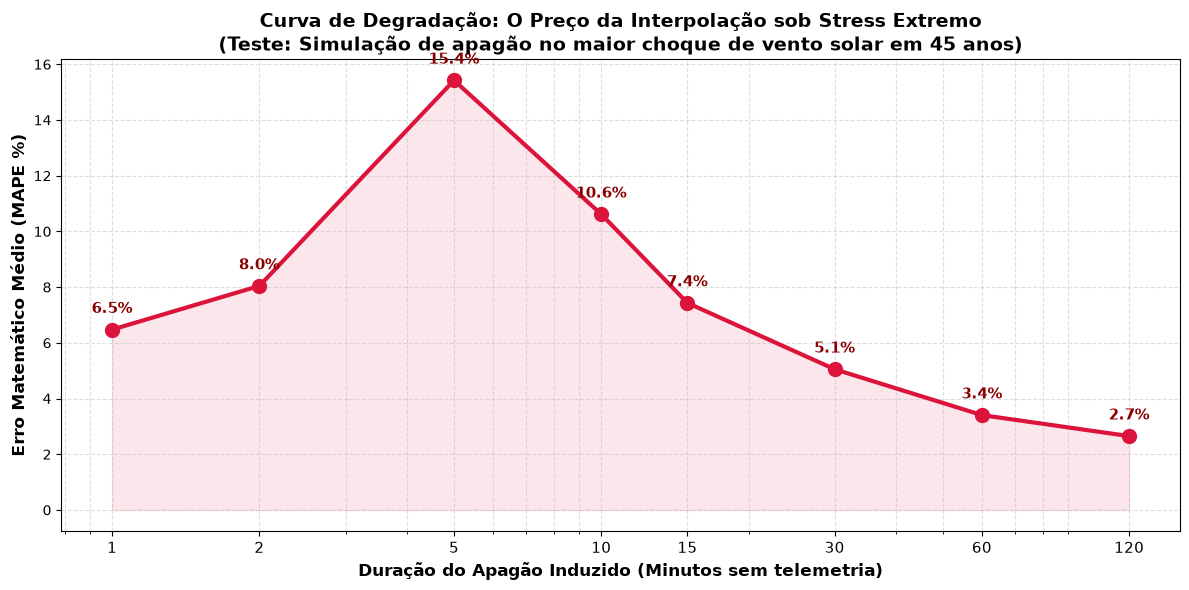

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

print("Inicializando a Análise de Tolerância a Gaps na Base Histórica...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    if 'Tempo' in df.columns:
        df.set_index('Tempo', inplace=True)
    
    componente = 'flow_speed'
    
    print("\n1. Varrendo 45 anos para encontrar o evento de maior aceleração (Choque Extremo)...")
    
    diferenca = df[componente].diff().abs()
    
    maiores_saltos = diferenca.sort_values(ascending=False)
    
    ponto_pico = None
    df_palco = None
    salto_maximo = 0
    
    print("À procura de um 'palco' de 4 horas sem falhas em redor de um mega choque...")
    # 3. Testamos os maiores choques até encontrar um que tenha 4 horas de gravação perfeita
    for instante, salto in maiores_saltos.head(500).items():
        # Tentamos criar um palco de 2h para trás e 2h para a frente
        inicio_teste = instante - pd.Timedelta(hours=2)
        fim_teste = instante + pd.Timedelta(hours=2)
        
        pedaco = df.loc[inicio_teste:fim_teste, [componente]]
        
        # 4 horas = 240 minutos (+1 do instante inicial) = 241 medições.
        # Condição de Ouro: Tem de ter o tamanho certo e ZERO (0) NaNs!
        if len(pedaco) == 241 and pedaco.isna().sum().iloc[0] == 0:
            ponto_pico = instante
            salto_maximo = salto
            df_palco = pedaco.copy()
            break # Encontrámos o palco perfeito, paramos a procura!
            
    if ponto_pico is None:
        print("Aviso: Não foi encontrado um choque perfeito sem falhas. A aumentar tolerância...")
        
    print(f"O choque mais abrupto e SEM FALHAS reais ocorreu em {ponto_pico.strftime('%d/%m/%Y %H:%M')} com um salto de {salto_maximo:.1f} km/s num só minuto!")
    
    idx_choque = df_palco.index.get_loc(ponto_pico)
    
    # Os tamanhos dos "buracos" artificiais (em minutos) que vamos induzir no pior local possível
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120] 
    erros_percentuais = []
    
    print("\n2. Simulando falhas de satélite no olho do furacão...")
    for tamanho in tamanhos_teste:
        df_sim = df_palco.copy()
        
        # Centramos o buraco fictício para coincidir exatamente com o choque
        inicio_buraco = max(0, idx_choque - (tamanho // 2))
        fim_buraco = min(len(df_sim), inicio_buraco + tamanho)
        
        # A realidade (a linha caótica)
        dados_verdadeiros = df_sim.iloc[inicio_buraco:fim_buraco][componente].copy()
        
        # Simulamos a falha: apagamos os dados no meio da onda de choque
        df_sim.iloc[inicio_buraco:fim_buraco, df_sim.columns.get_loc(componente)] = np.nan
        
        # A tentativa da matemática de adivinhar o buraco (traçando uma reta)
        df_sim['interpolado'] = df_sim[componente].interpolate(method='time')
        dados_matematica = df_sim.iloc[inicio_buraco:fim_buraco]['interpolado']
        
        # Calcular o Erro Percentual Absoluto Médio (MAPE) - o quão errada a linha ficou
        erro_mape = (np.abs((dados_verdadeiros - dados_matematica) / dados_verdadeiros).mean()) * 100
        erros_percentuais.append(erro_mape)
        
        print(f"[{tamanho:3} min offline] Erro induzido: {erro_mape:5.2f}% de falha na física")

    print("\n3. A gerar a Curva de Degradação...")
    
    plt.figure(figsize=(12, 6))
    plt.plot(tamanhos_teste, erros_percentuais, color='crimson', marker='o', linewidth=3, markersize=10, zorder=3)
    plt.fill_between(tamanhos_teste, erros_percentuais, color='crimson', alpha=0.1)
    
    # Anotações visuais da taxa de erro
    for i, erro in enumerate(erros_percentuais):
        plt.annotate(f"{erro:.1f}%", (tamanhos_teste[i], erros_percentuais[i]), 
                     textcoords="offset points", xytext=(0, 12), ha='center', 
                     fontweight='bold', color='darkred', fontsize=11)
        
    plt.title('Curva de Degradação: O Preço da Interpolação sob Stress Extremo\n(Teste: Simulação de apagão no maior choque de vento solar em 45 anos)', fontsize=14, fontweight='bold')
    plt.ylabel('Erro Matemático Médio (MAPE %)', fontsize=12, fontweight='bold')
    plt.xlabel('Duração do Apagão Induzido (Minutos sem telemetria)', fontsize=12, fontweight='bold')
    
    # Truque para uma escala logarítmica visual no eixo X para evidenciar como as falhas rápidas degradam
    plt.xscale('log')
    plt.xticks(tamanhos_teste, labels=[str(t) for t in tamanhos_teste], fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.4, zorder=0)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado.")

A iniciar Processamento Exaustivo (Força Bruta Vetorizada)...

1. A isolar os blocos de dados perfeitos...

2. A processar TODAS as combinações possíveis em 820735 blocos históricos...
[Gap   1 min] Analisados   6,943,986 cenários | Erro:  0.44% | Concluído em 5.04s
[Gap   2 min] Analisados  12,626,894 cenários | Erro:  0.53% | Concluído em 7.48s
[Gap   5 min] Analisados  24,928,775 cenários | Erro:  0.65% | Concluído em 12.71s
[Gap  10 min] Analisados  35,394,500 cenários | Erro:  0.74% | Concluído em 16.03s
[Gap  15 min] Analisados  38,937,780 cenários | Erro:  0.79% | Concluído em 16.04s
[Gap  30 min] Analisados  35,477,940 cenários | Erro:  0.90% | Concluído em 11.28s
[Gap  60 min] Analisados  24,150,000 cenários | Erro:  1.17% | Concluído em 4.79s
[Gap 120 min] Analisados  15,570,960 cenários | Erro:  1.76% | Concluído em 1.47s

3. A gerar a Curva de Degradação Absoluta...


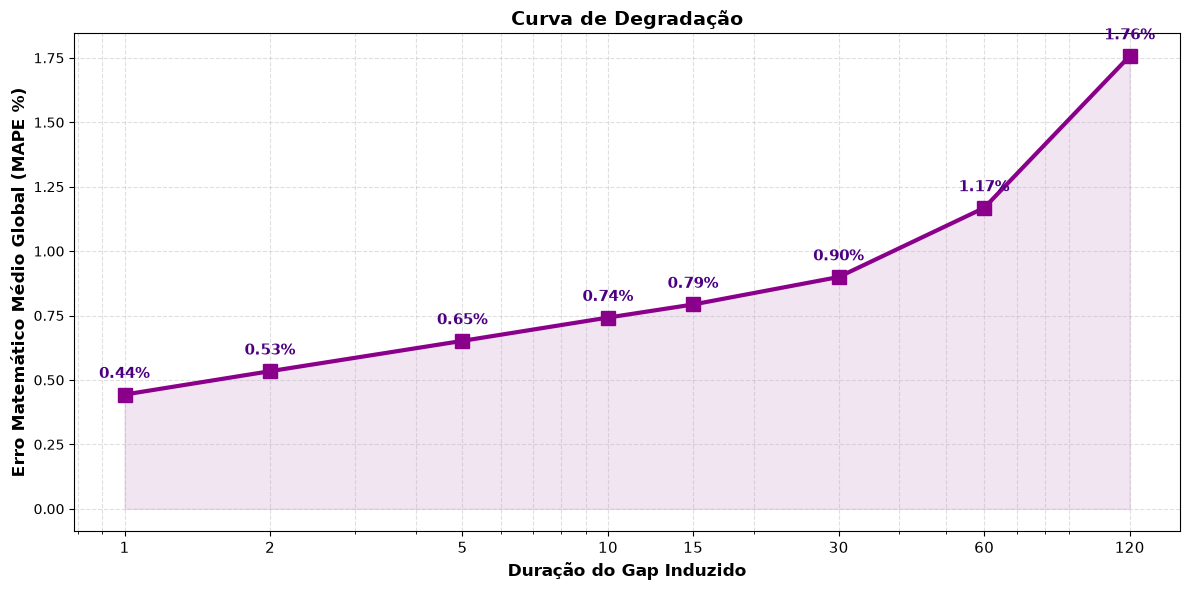

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo (Força Bruta Vetorizada)...")
arquivo_cache = "omni_20anos_limpo.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    componente = 'flow_speed'
    
    print("\n1. A isolar os blocos de dados perfeitos...")
    # Para testar um gap de tamanho K, precisamos de dados reais contínuos.
    # Vamos extrair todos os segmentos ininterruptos da história.
    tem_dado = df[componente].notna()
    ids_blocos = (~tem_dado).cumsum()[tem_dado]
    
    # Extrair os valores para uma lista de arrays NumPy (muito mais rápido que Pandas)
    segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    erros_medios = []
    
    print(f"\n2. A processar TODAS as combinações possíveis em {len(segmentos)} blocos históricos...")
    
    for k in tamanhos_teste:
        inicio_tempo = time.time()
        
        soma_erros_absolutos = 0.0
        total_pontos_testados = 0
        
        for seg in segmentos:
            N = len(seg)
            # Para abrir um buraco de tamanho 'k', o segmento precisa ter pelo menos 'k + 2' pontos
            # (1 âncora antes do buraco, os 'k' pontos do buraco, e 1 âncora depois do buraco)
            if N >= k + 2:
                # Âncoras esquerdas (antes do gap) e direitas (depois do gap) para TODOS os gaps possíveis neste segmento
                y_esq = seg[:-k-1]
                y_dir = seg[k+1:]
                
                # Vamos calcular o erro para cada um dos 'k' pontos dentro de todos os gaps simultaneamente
                for passo in range(1, k + 1):
                    # Qual é a percentagem da distância entre a âncora esquerda e direita?
                    alpha = passo / (k + 1)
                    
                    # A FÓRMULA MÁGICA: Interpolação linear de milhões de pontos num milissegundo
                    y_interpolado = y_esq + (y_dir - y_esq) * alpha
                    
                    # Os valores verdadeiros que estavam escondidos neste 'passo'
                    y_verdadeiro = seg[passo : passo + len(y_esq)]
                    
                    # Calcular o erro absoluto percentual (evitando divisão por zero)
                    y_verdadeiro_seguro = np.where(y_verdadeiro == 0, 0.001, y_verdadeiro)
                    erro_percentual = np.abs((y_verdadeiro - y_interpolado) / y_verdadeiro_seguro)
                    
                    soma_erros_absolutos += np.sum(erro_percentual)
                    total_pontos_testados += len(y_verdadeiro)
                    
        # Média global de todos os milhões de pontos testados
        erro_mape_global = (soma_erros_absolutos / total_pontos_testados) * 100
        erros_medios.append(erro_mape_global)
        
        tempo_gasto = time.time() - inicio_tempo
        print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | Erro: {erro_mape_global:5.2f}% | Concluído em {tempo_gasto:.2f}s")

    print("\n3. A gerar a Curva de Degradação Absoluta...")
    
    plt.figure(figsize=(12, 6))
    plt.plot(tamanhos_teste, erros_medios, color='darkmagenta', marker='s', linewidth=3, markersize=10, zorder=3)
    plt.fill_between(tamanhos_teste, erros_medios, color='purple', alpha=0.1)
    
    for i, erro in enumerate(erros_medios):
        plt.annotate(f"{erro:.2f}%", (tamanhos_teste[i], erros_medios[i]), 
                     textcoords="offset points", xytext=(0, 12), ha='center', 
                     fontweight='bold', color='indigo', fontsize=11)
        
    plt.title('Curva de Degradação', fontsize=14, fontweight='bold')
    plt.ylabel('Erro Matemático Médio Global (MAPE %)', fontsize=12, fontweight='bold')
    plt.xlabel('Duração do Gap Induzido', fontsize=12, fontweight='bold')
    
    plt.xscale('log')
    plt.xticks(tamanhos_teste, labels=[str(t) for t in tamanhos_teste], fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.4, zorder=0)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado.")

In [3]:
import pandas as pd
import numpy as np
import os

print("A carregar o cache histórico para correção...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    print("A exterminar os falsos positivos (Fill Values da NASA)...")
    
    # 1. Densidade: O vento solar normal tem entre 1 e 50 protões/cm3. 
    # Um valor de 999.99 é o código de erro da NASA. Vamos cortar tudo acima de 200.
    if 'proton_density' in df.columns:
        df['proton_density'] = df['proton_density'].where(df['proton_density'] < 200, np.nan)
        print("-> Densidade de Protões corrigida.")

    # 2. Campo Magnético: O campo magnético interplanetário raramente excede os 50 nT.
    # A NASA usa 999.9 ou 999.99 como erro. Cortamos tudo cujo valor absoluto passe de 200.
    colunas_mag = ['F', 'BX_GSE', 'BY_GSE', 'BZ_GSE', 'BY_GSM', 'BZ_GSM']
    for col in colunas_mag:
        if col in df.columns:
            df[col] = df[col].where(df[col].abs() < 200, np.nan)
    print("-> Campos Magnéticos corrigidos.")
    
    # 3. Temperatura e Velocidade (Garantia extra)
    if 'flow_speed' in df.columns:
        df['flow_speed'] = df['flow_speed'].where(df['flow_speed'] < 2000, np.nan)
        print("-> Velocidade corrigida.")
        
    if 'T' in df.columns:
        df['T'] = df['T'].where(df['T'] < 5000000, np.nan)
        print("-> Temperatura corrigida.")

    print("A reescrever o ficheiro de cache...")
    df.to_pickle(arquivo_cache)
    print("Sucesso! O seu cache está agora limpo e pronto para ciência exata.")

else:
    print(f"Erro: O ficheiro {arquivo_cache} não foi encontrado.")

A carregar o cache histórico para correção...
A exterminar os falsos positivos (Fill Values da NASA)...
-> Densidade de Protões corrigida.
-> Campos Magnéticos corrigidos.
-> Velocidade corrigida.
-> Temperatura corrigida.
A reescrever o ficheiro de cache...
Sucesso! O seu cache está agora limpo e pronto para ciência exata.


A iniciar Processamento Exaustivo Multi-Variável (WMAPE)...

A analisar: Velocidade (flow_speed)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | Erro Global:  0.47% | Tempo: 4.85s
[Gap   2 min] Analisados  12,901,056 cenários | Erro Global:  0.56% | Tempo: 7.24s
[Gap   5 min] Analisados  25,428,270 cenários | Erro Global:  0.69% | Tempo: 11.66s
[Gap  10 min] Analisados  36,019,320 cenários | Erro Global:  0.78% | Tempo: 14.92s
[Gap  15 min] Analisados  39,545,205 cenários | Erro Global:  0.84% | Tempo: 14.49s
[Gap  30 min] Analisados  35,857,140 cenários | Erro Global:  0.95% | Tempo: 11.16s
[Gap  60 min] Analisados  24,280,260 cenários | Erro Global:  1.23% | Tempo: 4.74s
[Gap 120 min] Analisados  15,578,640 cenários | Erro Global:  1.84% | Tempo: 1.38s

A analisar: Densidade de Protões (proton_density)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | Erro Global:  3.53% | Tempo: 4

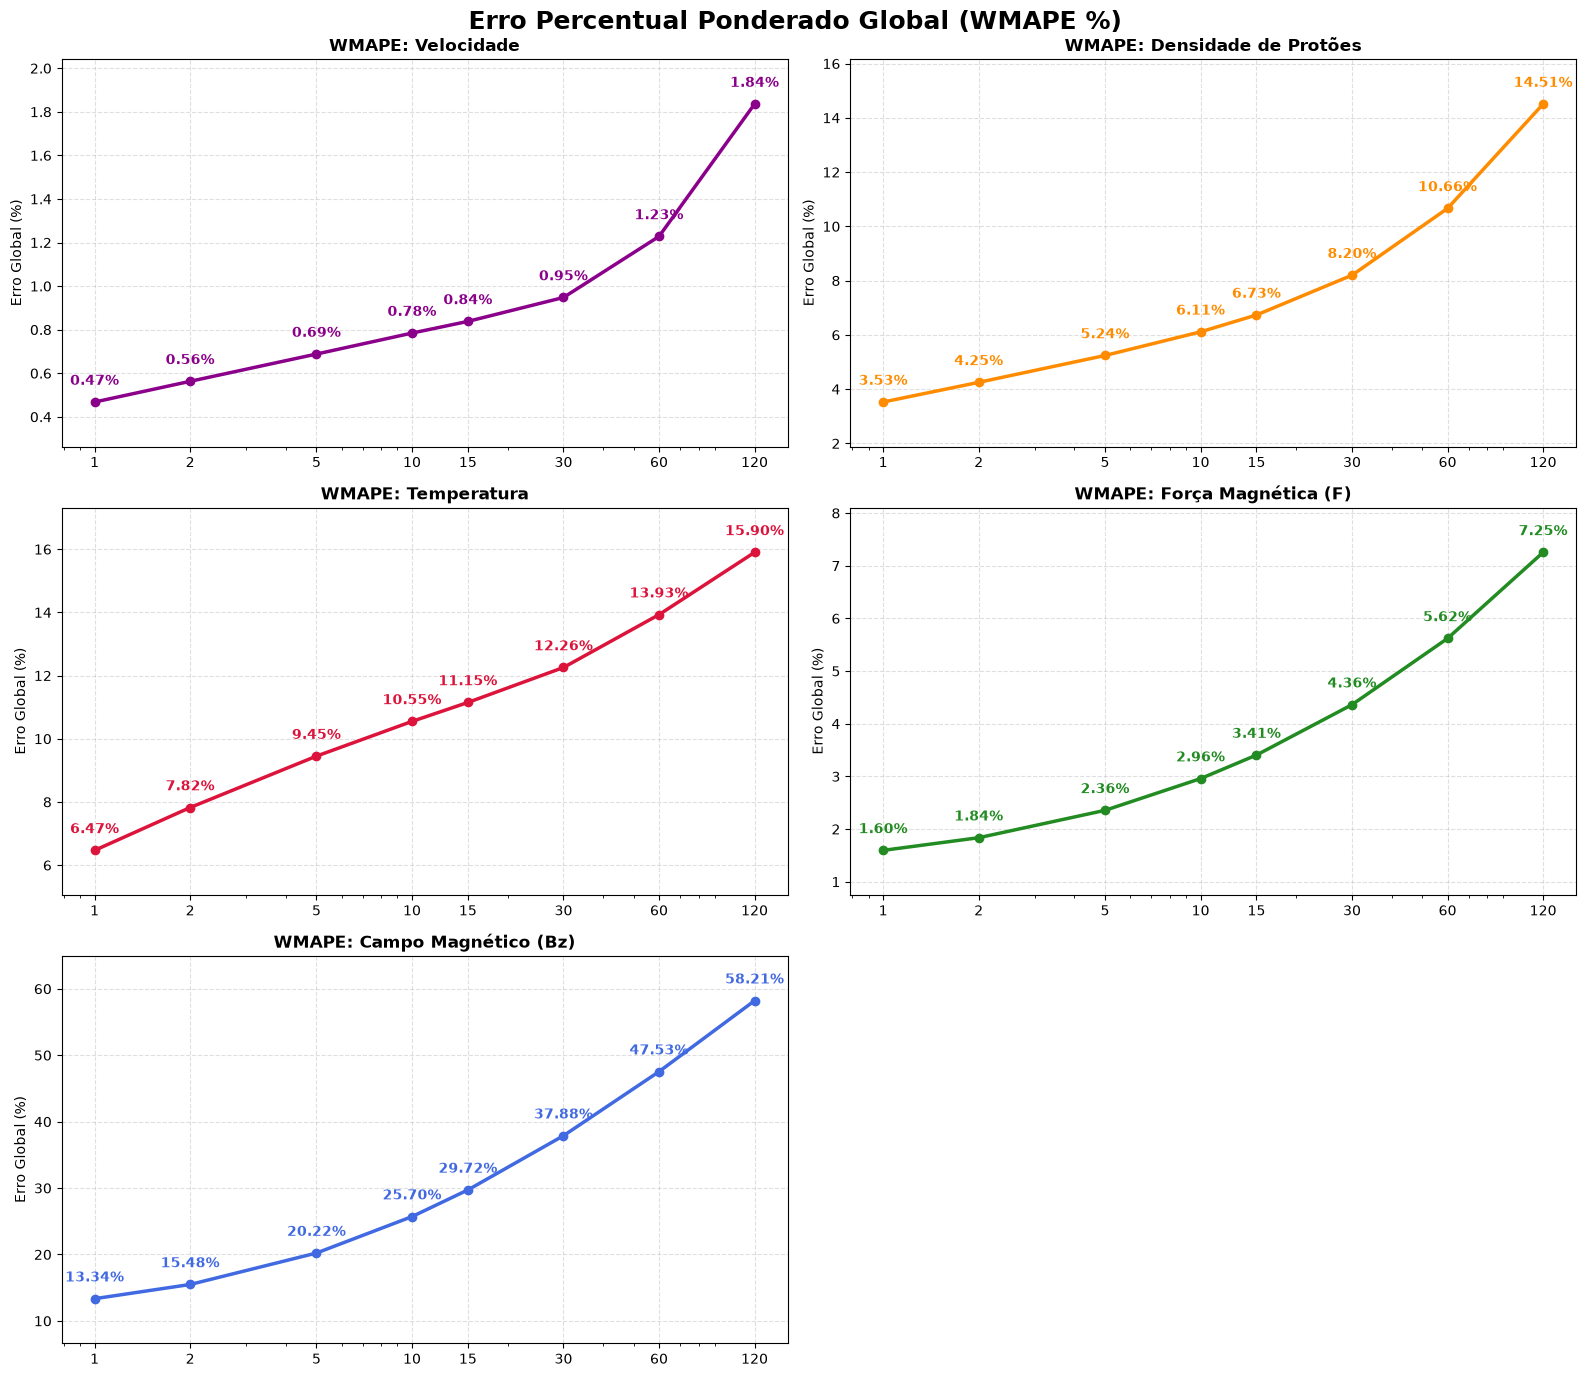

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo Multi-Variável (WMAPE)...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    variaveis = {
        'flow_speed': {'nome': 'Velocidade', 'cor': 'darkmagenta'},
        'proton_density': {'nome': 'Densidade de Protões', 'cor': 'darkorange'},
        'T': {'nome': 'Temperatura', 'cor': 'crimson'},
        'F': {'nome': 'Força Magnética (F)', 'cor': 'forestgreen'},
        'BZ_GSM': {'nome': 'Campo Magnético (Bz)', 'cor': 'royalblue'}
    }
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    resultados = {var: [] for var in variaveis.keys()}
    
    for componente, info in variaveis.items():
        print(f"\n" + "="*50)
        print(f"A analisar: {info['nome']} ({componente})")
        print("="*50)
        
        tem_dado = df[componente].notna()
        ids_blocos = (~tem_dado).cumsum()[tem_dado]
        segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
        
        print(f"Encontrados {len(segmentos):,} blocos ininterruptos históricos.")
        
        for k in tamanhos_teste:
            inicio_tempo = time.time()
            soma_erro_absoluto = 0.0
            soma_sinal_absoluto = 0.0
            total_pontos_testados = 0
            
            for seg in segmentos:
                N = len(seg)
                if N >= k + 2:
                    y_esq = seg[:-k-1]
                    y_dir = seg[k+1:]
                    
                    for passo in range(1, k + 1):
                        alpha = passo / (k + 1)
                        y_interpolado = y_esq + (y_dir - y_esq) * alpha
                        y_verdadeiro = seg[passo : passo + len(y_esq)]
                        
                        soma_erro_absoluto += np.sum(np.abs(y_verdadeiro - y_interpolado))
                        soma_sinal_absoluto += np.sum(np.abs(y_verdadeiro))
                        total_pontos_testados += len(y_verdadeiro)
                        
            wmape = (soma_erro_absoluto / soma_sinal_absoluto) * 100 if soma_sinal_absoluto > 0 else 0
            resultados[componente].append(wmape)
            tempo_gasto = time.time() - inicio_tempo
            
            print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | Erro Global: {wmape:5.2f}% | Tempo: {tempo_gasto:.2f}s")

    print("\nA gerar a Matriz de Gráficos (3x2)...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, (componente, info) in enumerate(variaveis.items()):
        ax = axes[i]
        erros = resultados[componente]
        
        ax.plot(tamanhos_teste, erros, color=info['cor'], marker='o', linewidth=2.5)
        ax.set_title(f"WMAPE: {info['nome']}", fontweight='bold')
        ax.set_ylabel('Erro Global (%)')
        ax.set_xscale('log')
        ax.set_xticks(tamanhos_teste)
        ax.set_xticklabels(tamanhos_teste)
        ax.grid(True, ls="--", alpha=0.4)
        ax.margins(y=0.15) # Dá espaço para a anotação respirar e não ser cortada
        
        # Anotar o WMAPE em TODOS os pontos!
        for j, val in enumerate(erros):
            ax.annotate(f"{val:.2f}%", (tamanhos_teste[j], val), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', va='bottom', color=info['cor'], fontweight='bold', fontsize=10)

    axes[5].set_visible(False)
    plt.suptitle('Erro Percentual Ponderado Global (WMAPE %)', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Ficheiro de cache não encontrado.")

A iniciar Processamento Exaustivo Multi-Variável (MAE)...

A analisar: Velocidade (flow_speed)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | MAE:     1.98 | Tempo: 2.97s
[Gap   2 min] Analisados  12,901,056 cenários | MAE:     2.39 | Tempo: 4.48s
[Gap   5 min] Analisados  25,428,270 cenários | MAE:     2.91 | Tempo: 7.53s
[Gap  10 min] Analisados  36,019,320 cenários | MAE:     3.31 | Tempo: 9.25s
[Gap  15 min] Analisados  39,545,205 cenários | MAE:     3.52 | Tempo: 9.28s
[Gap  30 min] Analisados  35,857,140 cenários | MAE:     3.96 | Tempo: 6.44s
[Gap  60 min] Analisados  24,280,260 cenários | MAE:     5.12 | Tempo: 2.78s
[Gap 120 min] Analisados  15,578,640 cenários | MAE:     7.74 | Tempo: 0.85s

A analisar: Densidade de Protões (proton_density)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | MAE:     0.22 | Tempo: 3.14s
[Gap   2 min] Analisados  12,901,056 cenários | MAE:   

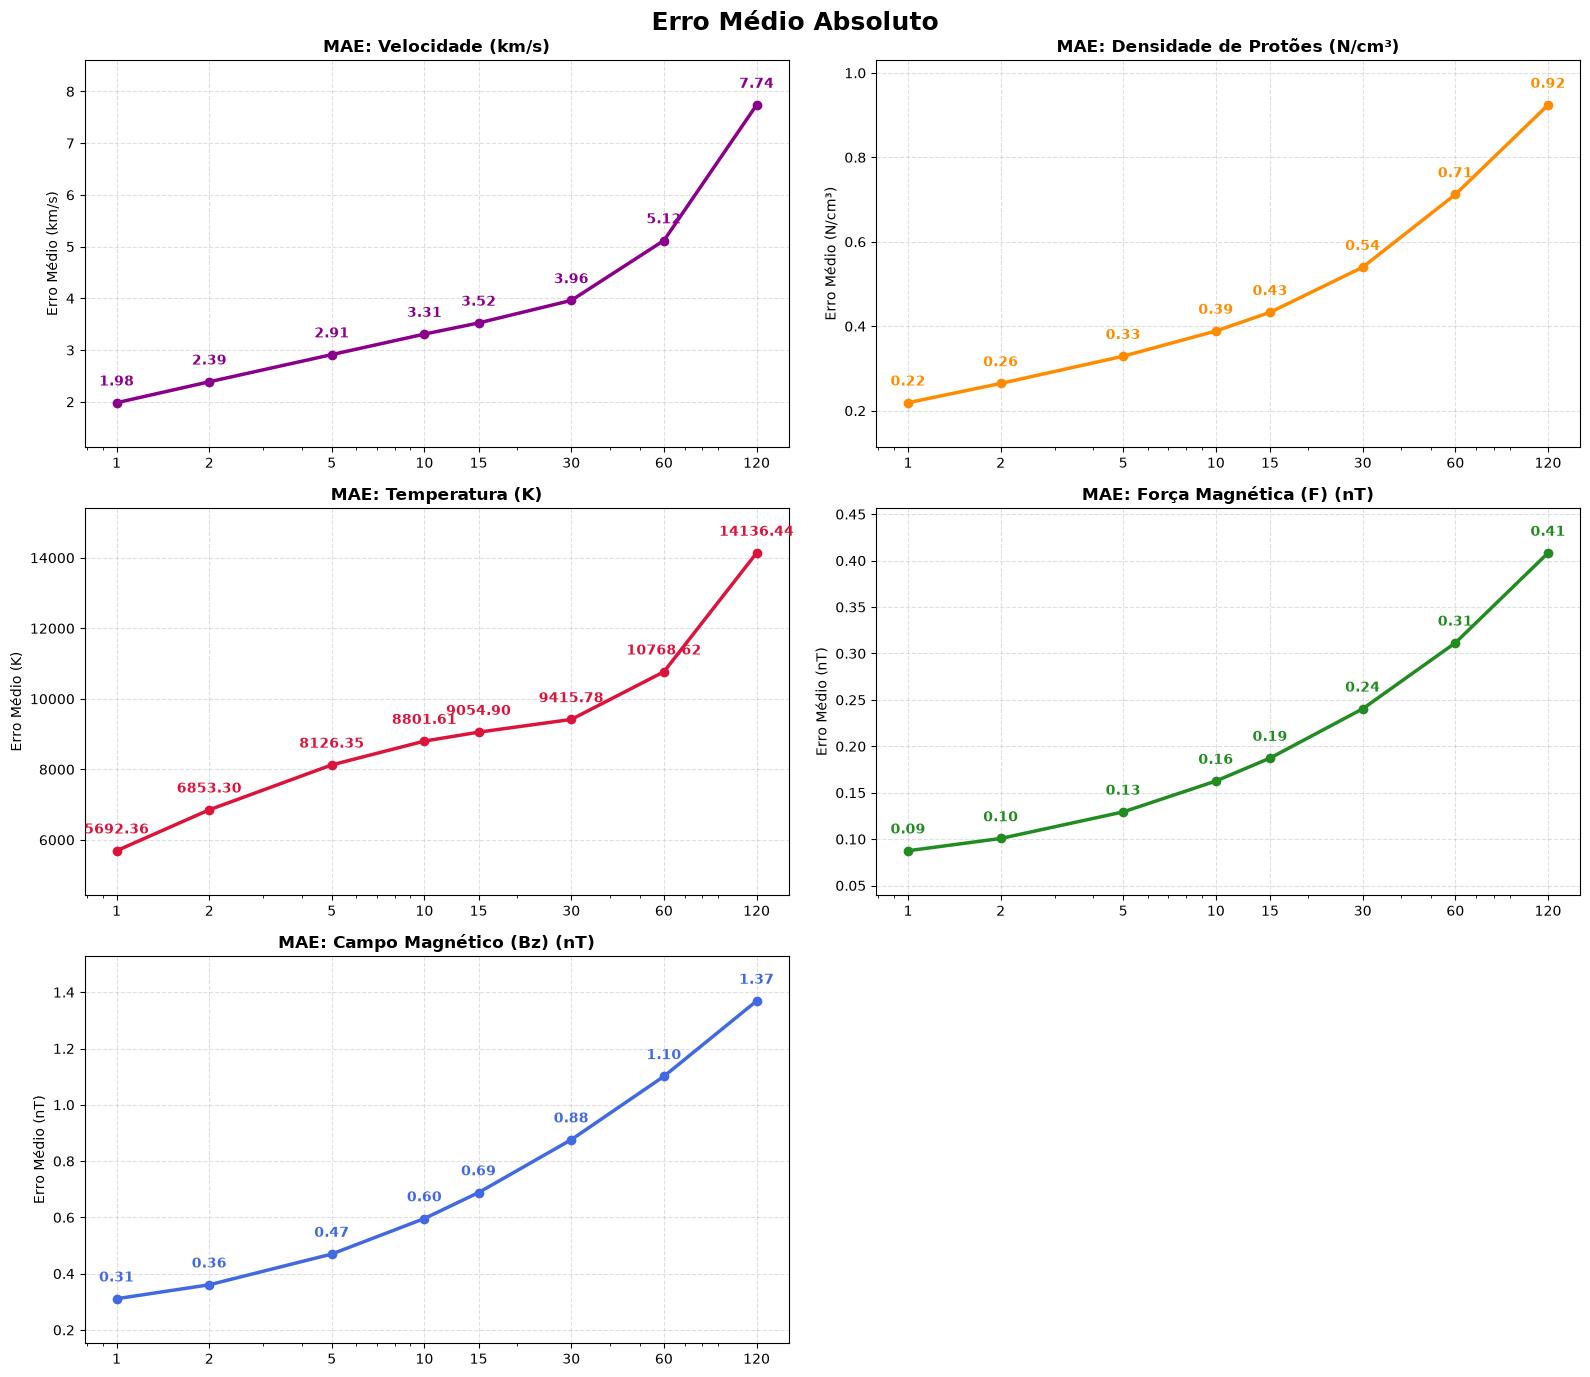

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo Multi-Variável (MAE)...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    variaveis = {
        'flow_speed': {'nome': 'Velocidade', 'unidade': 'km/s', 'cor': 'darkmagenta'},
        'proton_density': {'nome': 'Densidade de Protões', 'unidade': 'N/cm³', 'cor': 'darkorange'},
        'T': {'nome': 'Temperatura', 'unidade': 'K', 'cor': 'crimson'},
        'F': {'nome': 'Força Magnética (F)', 'unidade': 'nT', 'cor': 'forestgreen'},
        'BZ_GSM': {'nome': 'Campo Magnético (Bz)', 'unidade': 'nT', 'cor': 'royalblue'}
    }
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    resultados = {var: [] for var in variaveis.keys()}
    
    for componente, info in variaveis.items():
        print(f"\n" + "="*50)
        print(f"A analisar: {info['nome']} ({componente})")
        print("="*50)
        
        tem_dado = df[componente].notna()
        ids_blocos = (~tem_dado).cumsum()[tem_dado]
        segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
        
        print(f"Encontrados {len(segmentos):,} blocos ininterruptos históricos.")
        
        for k in tamanhos_teste:
            inicio_tempo = time.time()
            soma_erros_absolutos = 0.0
            total_pontos_testados = 0
            
            for seg in segmentos:
                N = len(seg)
                if N >= k + 2:
                    y_esq = seg[:-k-1]
                    y_dir = seg[k+1:]
                    
                    for passo in range(1, k + 1):
                        alpha = passo / (k + 1)
                        y_interpolado = y_esq + (y_dir - y_esq) * alpha
                        y_verdadeiro = seg[passo : passo + len(y_esq)]
                        
                        soma_erros_absolutos += np.sum(np.abs(y_verdadeiro - y_interpolado))
                        total_pontos_testados += len(y_verdadeiro)
            
            mae = soma_erros_absolutos / total_pontos_testados if total_pontos_testados > 0 else 0
            resultados[componente].append(mae)
            tempo_gasto = time.time() - inicio_tempo
            
            print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | MAE: {mae:8.2f} | Tempo: {tempo_gasto:.2f}s")

    print("\nA gerar a Matriz de Gráficos (3x2)...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, (componente, info) in enumerate(variaveis.items()):
        ax = axes[i]
        erros = resultados[componente]
        
        ax.plot(tamanhos_teste, erros, color=info['cor'], marker='o', linewidth=2.5)
        ax.set_title(f"MAE: {info['nome']} ({info['unidade']})", fontweight='bold')
        ax.set_ylabel(f'Erro Médio ({info["unidade"]})')
        ax.set_xscale('log')
        ax.set_xticks(tamanhos_teste)
        ax.set_xticklabels(tamanhos_teste)
        ax.grid(True, ls="--", alpha=0.4)
        ax.margins(y=0.15)
        
        # Anotar o MAE em TODOS os pontos
        for j, val in enumerate(erros):
            ax.annotate(f"{val:.2f}", (tamanhos_teste[j], val), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', va='bottom', color=info['cor'], fontweight='bold', fontsize=10)

    axes[5].set_visible(False)
    plt.suptitle('Erro Médio Absoluto', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Ficheiro não encontrado.")

A iniciar Processamento Exaustivo Multi-Variável (RMSE)...

A analisar: Velocidade (flow_speed)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | RMSE:     3.87 | Tempo: 3.09s
[Gap   2 min] Analisados  12,901,056 cenários | RMSE:     4.54 | Tempo: 4.65s
[Gap   5 min] Analisados  25,428,270 cenários | RMSE:     5.34 | Tempo: 7.71s
[Gap  10 min] Analisados  36,019,320 cenários | RMSE:     5.89 | Tempo: 10.26s
[Gap  15 min] Analisados  39,545,205 cenários | RMSE:     6.18 | Tempo: 10.58s
[Gap  30 min] Analisados  35,857,140 cenários | RMSE:     6.85 | Tempo: 7.38s
[Gap  60 min] Analisados  24,280,260 cenários | RMSE:     8.75 | Tempo: 3.22s
[Gap 120 min] Analisados  15,578,640 cenários | RMSE:    12.26 | Tempo: 0.95s

A analisar: Densidade de Protões (proton_density)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | RMSE:     0.46 | Tempo: 3.19s
[Gap   2 min] Analisados  12,901,056 cenári

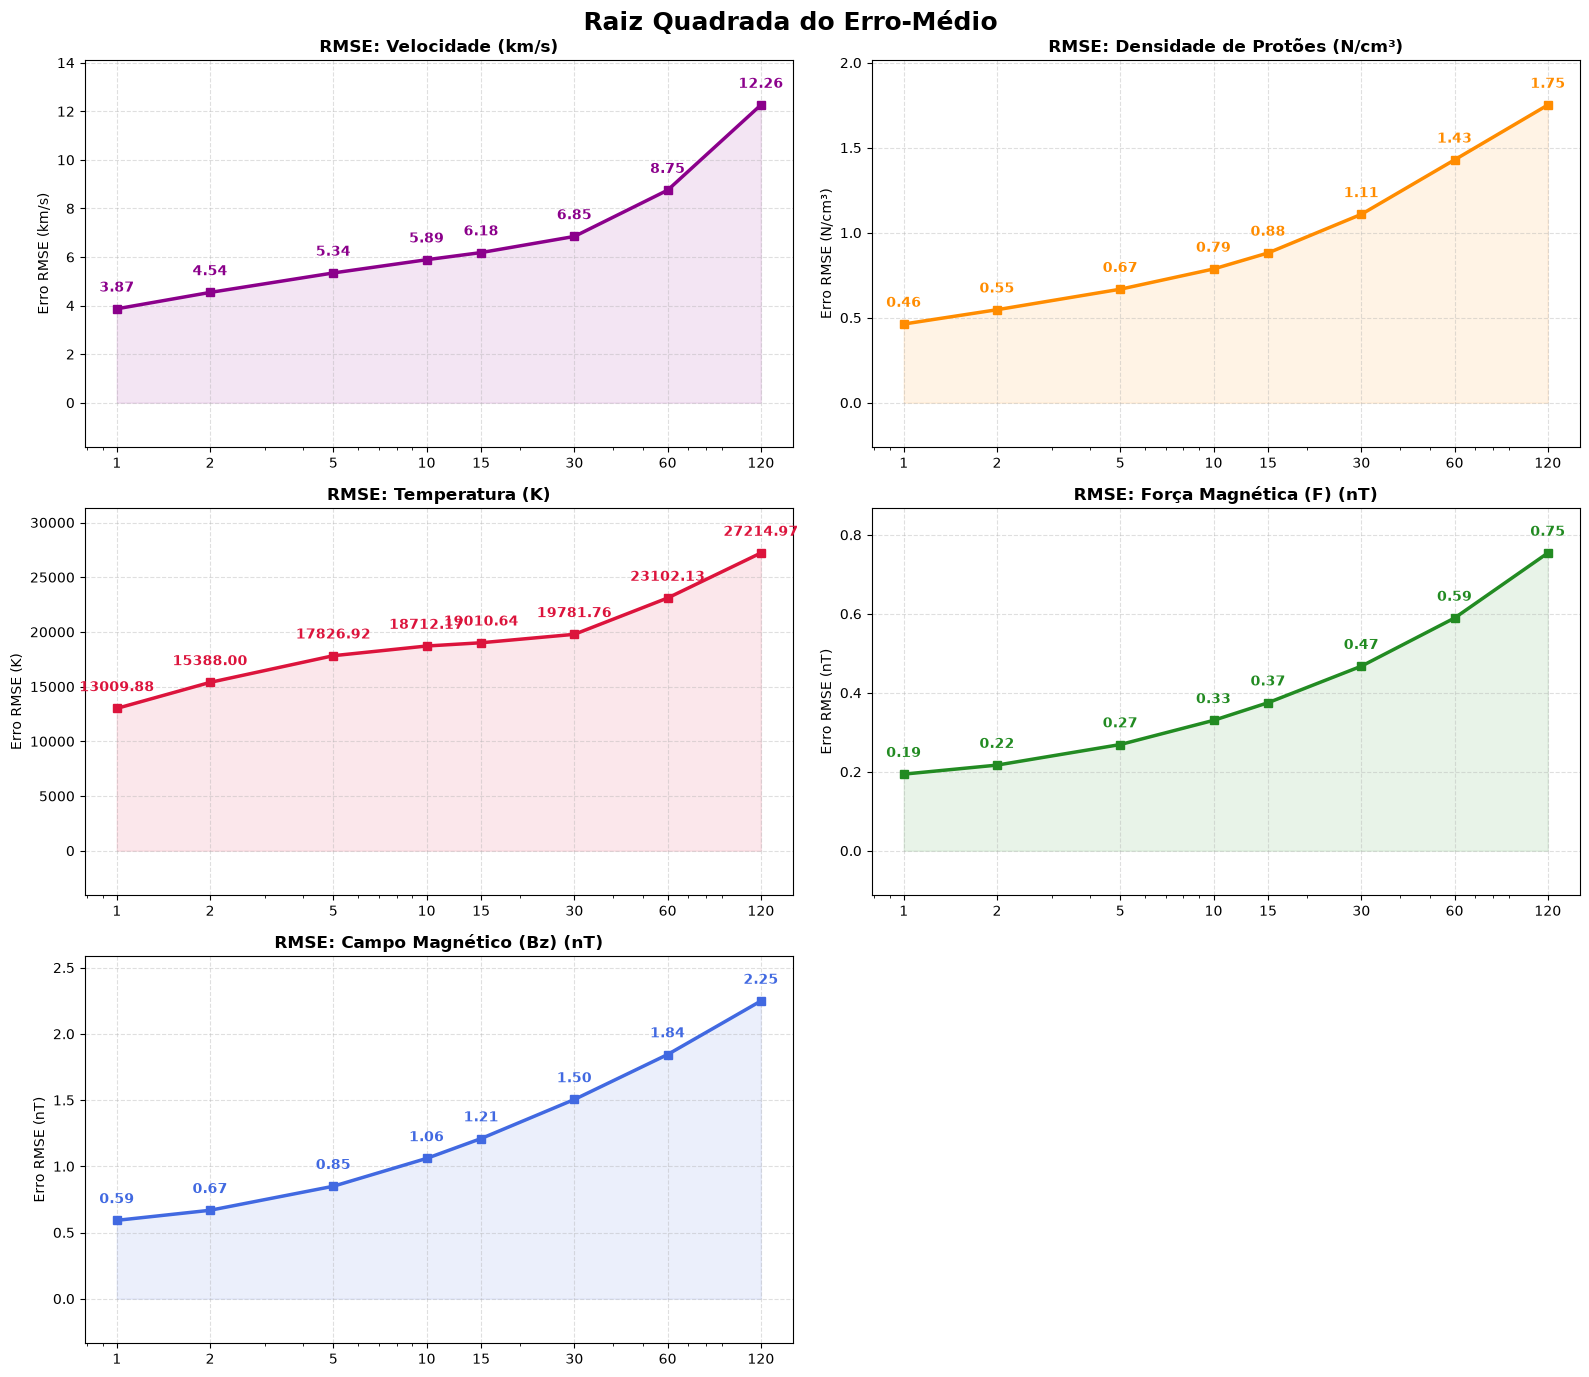

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo Multi-Variável (RMSE)...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    variaveis = {
        'flow_speed': {'nome': 'Velocidade', 'unidade': 'km/s', 'cor': 'darkmagenta'},
        'proton_density': {'nome': 'Densidade de Protões', 'unidade': 'N/cm³', 'cor': 'darkorange'},
        'T': {'nome': 'Temperatura', 'unidade': 'K', 'cor': 'crimson'},
        'F': {'nome': 'Força Magnética (F)', 'unidade': 'nT', 'cor': 'forestgreen'},
        'BZ_GSM': {'nome': 'Campo Magnético (Bz)', 'unidade': 'nT', 'cor': 'royalblue'}
    }
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    resultados = {var: [] for var in variaveis.keys()}
    
    for componente, info in variaveis.items():
        print(f"\n" + "="*50)
        print(f"A analisar: {info['nome']} ({componente})")
        print("="*50)
        
        tem_dado = df[componente].notna()
        ids_blocos = (~tem_dado).cumsum()[tem_dado]
        segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
        
        print(f"Encontrados {len(segmentos):,} blocos ininterruptos históricos.")
        
        for k in tamanhos_teste:
            inicio_tempo = time.time()
            soma_erros_quadrados = 0.0
            total_pontos_testados = 0
            
            for seg in segmentos:
                N = len(seg)
                if N >= k + 2:
                    y_esq = seg[:-k-1]
                    y_dir = seg[k+1:]
                    
                    for passo in range(1, k + 1):
                        alpha = passo / (k + 1)
                        y_interpolado = y_esq + (y_dir - y_esq) * alpha
                        y_verdadeiro = seg[passo : passo + len(y_esq)]
                        
                        soma_erros_quadrados += np.sum((y_verdadeiro - y_interpolado)**2)
                        total_pontos_testados += len(y_verdadeiro)
            
            rmse = np.sqrt(soma_erros_quadrados / total_pontos_testados) if total_pontos_testados > 0 else 0
            resultados[componente].append(rmse)
            tempo_gasto = time.time() - inicio_tempo
            
            print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | RMSE: {rmse:8.2f} | Tempo: {tempo_gasto:.2f}s")

    print("\nA gerar a Matriz de Gráficos (3x2)...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, (componente, info) in enumerate(variaveis.items()):
        ax = axes[i]
        erros = resultados[componente]
        
        ax.plot(tamanhos_teste, erros, color=info['cor'], marker='s', linewidth=2.5)
        ax.fill_between(tamanhos_teste, erros, color=info['cor'], alpha=0.1)
        ax.set_title(f"RMSE: {info['nome']} ({info['unidade']})", fontweight='bold')
        ax.set_ylabel(f'Erro RMSE ({info["unidade"]})')
        ax.set_xscale('log')
        ax.set_xticks(tamanhos_teste)
        ax.set_xticklabels(tamanhos_teste)
        ax.grid(True, ls="--", alpha=0.4)
        ax.margins(y=0.15)
        
        # Anotar o RMSE em TODOS os pontos
        for j, val in enumerate(erros):
            ax.annotate(f"{val:.2f}", (tamanhos_teste[j], val), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', va='bottom', color=info['cor'], fontweight='bold', fontsize=10)

    axes[5].set_visible(False)
    plt.suptitle('Raiz Quadrada do Erro-Médio ', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Ficheiro não encontrado.")

A iniciar Processamento Exaustivo Multi-Variável (R²)...

A analisar: Velocidade (flow_speed)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | R²:     1.00 | Tempo: 4.67s
[Gap   2 min] Analisados  12,901,056 cenários | R²:     1.00 | Tempo: 6.98s
[Gap   5 min] Analisados  25,428,270 cenários | R²:     1.00 | Tempo: 11.90s
[Gap  10 min] Analisados  36,019,320 cenários | R²:     1.00 | Tempo: 14.76s
[Gap  15 min] Analisados  39,545,205 cenários | R²:     1.00 | Tempo: 14.38s
[Gap  30 min] Analisados  35,857,140 cenários | R²:     1.00 | Tempo: 10.48s
[Gap  60 min] Analisados  24,280,260 cenários | R²:     0.99 | Tempo: 4.53s
[Gap 120 min] Analisados  15,578,640 cenários | R²:     0.99 | Tempo: 1.40s

A analisar: Densidade de Protões (proton_density)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | R²:     0.99 | Tempo: 4.63s
[Gap   2 min] Analisados  12,901,056 cenários | R²:     0.99 

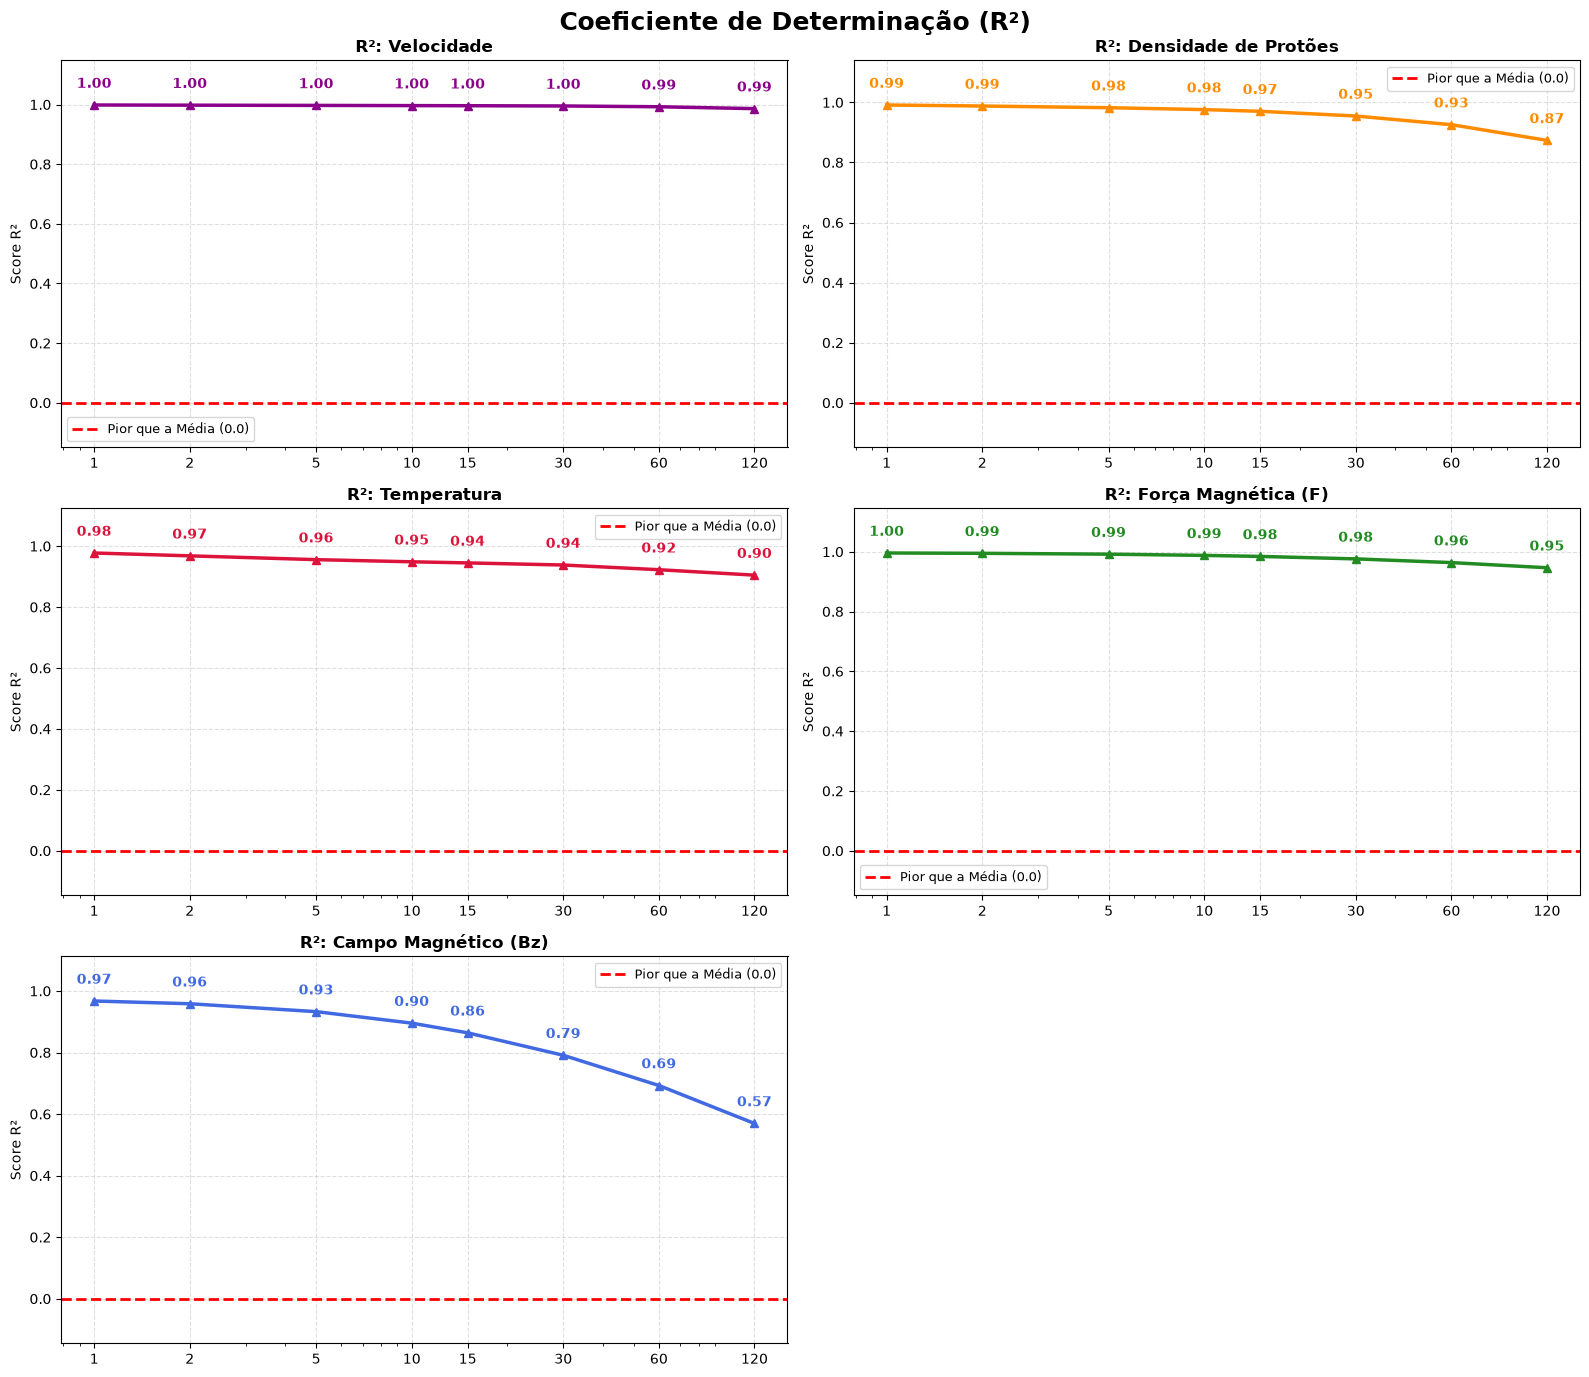

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo Multi-Variável (R²)...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    variaveis = {
        'flow_speed': {'nome': 'Velocidade', 'cor': 'darkmagenta'},
        'proton_density': {'nome': 'Densidade de Protões', 'cor': 'darkorange'},
        'T': {'nome': 'Temperatura', 'cor': 'crimson'},
        'F': {'nome': 'Força Magnética (F)', 'cor': 'forestgreen'},
        'BZ_GSM': {'nome': 'Campo Magnético (Bz)', 'cor': 'royalblue'}
    }
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    resultados = {var: [] for var in variaveis.keys()}
    
    for componente, info in variaveis.items():
        print(f"\n" + "="*50)
        print(f"A analisar: {info['nome']} ({componente})")
        print("="*50)
        
        tem_dado = df[componente].notna()
        media_global = df[componente].mean() 
        
        ids_blocos = (~tem_dado).cumsum()[tem_dado]
        segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
        
        print(f"Encontrados {len(segmentos):,} blocos ininterruptos históricos.")
        
        for k in tamanhos_teste:
            inicio_tempo = time.time()
            ss_res = 0.0
            ss_tot = 0.0
            total_pontos_testados = 0
            
            for seg in segmentos:
                N = len(seg)
                if N >= k + 2:
                    y_esq = seg[:-k-1]
                    y_dir = seg[k+1:]
                    
                    for passo in range(1, k + 1):
                        alpha = passo / (k + 1)
                        y_interpolado = y_esq + (y_dir - y_esq) * alpha
                        y_verdadeiro = seg[passo : passo + len(y_esq)]
                        
                        ss_res += np.sum((y_verdadeiro - y_interpolado)**2)
                        ss_tot += np.sum((y_verdadeiro - media_global)**2)
                        total_pontos_testados += len(y_verdadeiro)
            
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            resultados[componente].append(r2)
            tempo_gasto = time.time() - inicio_tempo
            
            print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | R²: {r2:8.2f} | Tempo: {tempo_gasto:.2f}s")
            
    print("\nA gerar a Matriz de Gráficos (3x2)...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, (componente, info) in enumerate(variaveis.items()):
        ax = axes[i]
        erros = resultados[componente]
        
        ax.plot(tamanhos_teste, erros, color=info['cor'], marker='^', linewidth=2.5)
        
        # A Linha Vermelha que marca quando a interpolação fica pior que a Média global
        ax.axhline(0, color='red', linewidth=2, linestyle='--', label='Pior que a Média (0.0)')
        
        ax.set_title(f"R²: {info['nome']}", fontweight='bold')
        ax.set_ylabel('Score R²')
        ax.set_xscale('log')
        ax.set_xticks(tamanhos_teste)
        ax.set_xticklabels(tamanhos_teste)
        ax.grid(True, ls="--", alpha=0.4)
        ax.margins(y=0.15)
        ax.legend(fontsize=9, loc='best')
        
        # Anotar o R² em TODOS os pontos
        for j, val in enumerate(erros):
            ax.annotate(f"{val:.2f}", (tamanhos_teste[j], val), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', va='bottom', color=info['cor'], fontweight='bold', fontsize=10)

    axes[5].set_visible(False)
    plt.suptitle('Coeficiente de Determinação (R²)', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Ficheiro não encontrado.")

A iniciar Processamento Exaustivo Multi-Variável (MDA)...

A analisar: Velocidade (flow_speed)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | MDA: 70.43% | Tempo: 3.31s
[Gap   2 min] Analisados  12,901,056 cenários | MDA: 60.17% | Tempo: 4.44s
[Gap   5 min] Analisados  25,428,270 cenários | MDA: 51.68% | Tempo: 6.97s
[Gap  10 min] Analisados  36,019,320 cenários | MDA: 48.62% | Tempo: 8.54s
[Gap  15 min] Analisados  39,545,205 cenários | MDA: 47.39% | Tempo: 8.51s
[Gap  30 min] Analisados  35,857,140 cenários | MDA: 45.98% | Tempo: 5.87s
[Gap  60 min] Analisados  24,280,260 cenários | MDA: 45.73% | Tempo: 2.49s
[Gap 120 min] Analisados  15,578,640 cenários | MDA: 46.93% | Tempo: 0.76s

A analisar: Densidade de Protões (proton_density)
Encontrados 844,180 blocos ininterruptos históricos.
[Gap   1 min] Analisados   7,099,848 cenários | MDA: 69.81% | Tempo: 3.23s
[Gap   2 min] Analisados  12,901,056 cenários | MDA: 59.15% | Tempo: 4.45

/tmp/ipykernel_889/1717797004.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='lower left')
/tmp/ipykernel_889/1717797004.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='lower left')
/tmp/ipykernel_889/1717797004.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='lower left')
/tmp/ipykernel_889/1717797004.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc='lower left')
/tmp

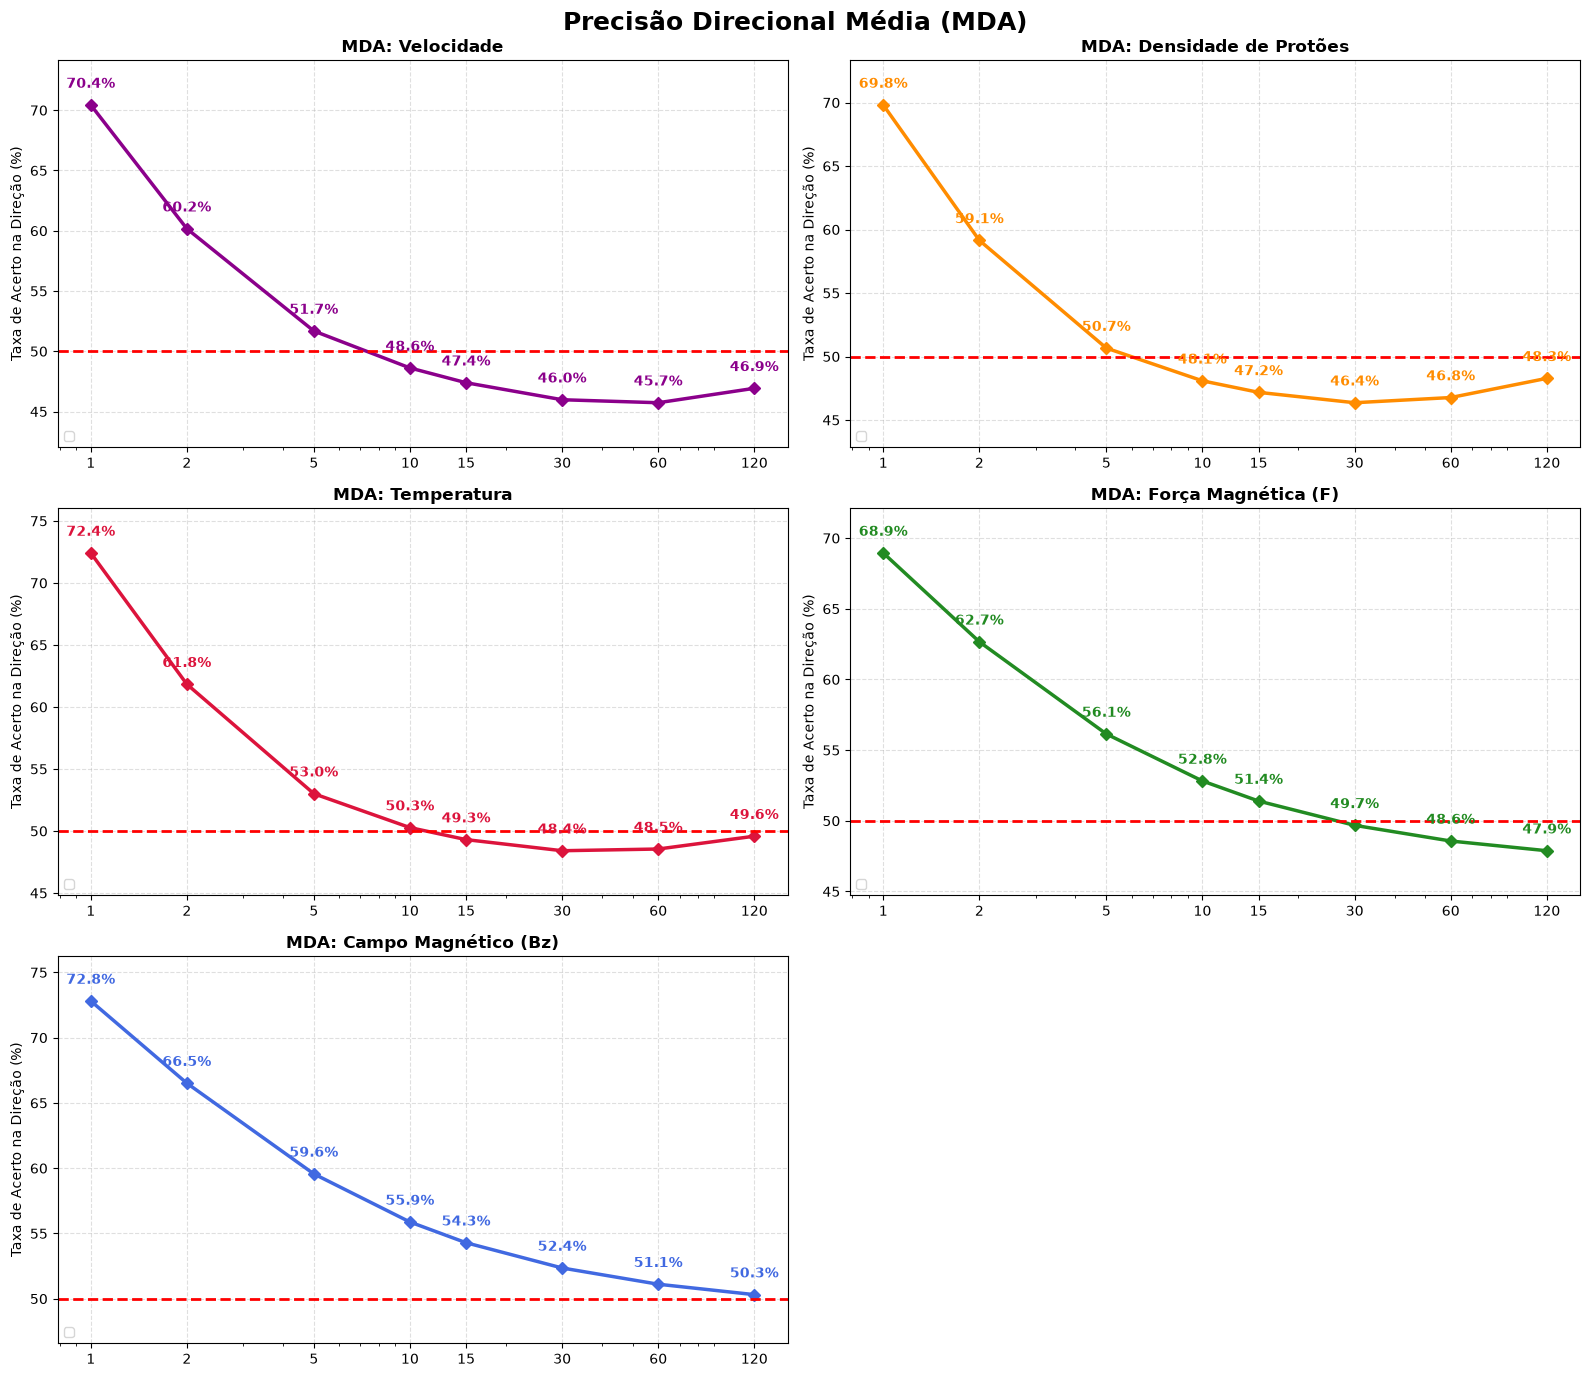

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("A iniciar Processamento Exaustivo Multi-Variável (MDA)...")
arquivo_cache = "omni_dados.pkl"

if os.path.exists(arquivo_cache):
    df = pd.read_pickle(arquivo_cache)
    
    variaveis = {
        'flow_speed': {'nome': 'Velocidade', 'cor': 'darkmagenta'},
        'proton_density': {'nome': 'Densidade de Protões', 'cor': 'darkorange'},
        'T': {'nome': 'Temperatura', 'cor': 'crimson'},
        'F': {'nome': 'Força Magnética (F)', 'cor': 'forestgreen'},
        'BZ_GSM': {'nome': 'Campo Magnético (Bz)', 'cor': 'royalblue'}
    }
    
    tamanhos_teste = [1, 2, 5, 10, 15, 30, 60, 120]
    resultados = {var: [] for var in variaveis.keys()}
    
    for componente, info in variaveis.items():
        print(f"\n" + "="*50)
        print(f"A analisar: {info['nome']} ({componente})")
        print("="*50)
        
        tem_dado = df[componente].notna()
        ids_blocos = (~tem_dado).cumsum()[tem_dado]
        segmentos = [grupo.values for _, grupo in df[componente][tem_dado].groupby(ids_blocos)]
        
        print(f"Encontrados {len(segmentos):,} blocos ininterruptos históricos.")
        
        for k in tamanhos_teste:
            inicio_tempo = time.time()
            acertos_direcao = 0
            total_pontos_testados = 0
            
            for seg in segmentos:
                N = len(seg)
                if N >= k + 2:
                    y_esq = seg[:-k-1]
                    y_dir = seg[k+1:]
                    
                    dir_interpolacao = np.sign(y_dir - y_esq)
                    
                    for passo in range(1, k + 1):
                        y_verdadeiro_atual = seg[passo : passo + len(y_esq)]
                        y_verdadeiro_anterior = seg[passo - 1 : passo - 1 + len(y_esq)]
                        
                        dir_real = np.sign(y_verdadeiro_atual - y_verdadeiro_anterior)
                        
                        acertos_direcao += np.sum(dir_real == dir_interpolacao)
                        total_pontos_testados += len(y_verdadeiro_atual)
            
            mda = (acertos_direcao / total_pontos_testados) * 100 if total_pontos_testados > 0 else 0
            resultados[componente].append(mda)
            tempo_gasto = time.time() - inicio_tempo
            
            print(f"[Gap {k:3} min] Analisados {total_pontos_testados:11,} cenários | MDA: {mda:5.2f}% | Tempo: {tempo_gasto:.2f}s")

    print("\nA gerar a Matriz de Gráficos (3x2)...")
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, (componente, info) in enumerate(variaveis.items()):
        ax = axes[i]
        erros = resultados[componente]
        
        ax.plot(tamanhos_teste, erros, color=info['cor'], marker='D', linewidth=2.5)
        
        # A Linha Vermelha do "Cara ou Coroa"
        ax.axhline(50, color='red', linewidth=2, linestyle='--')
        
        ax.set_title(f"MDA: {info['nome']}", fontweight='bold')
        ax.set_ylabel('Taxa de Acerto na Direção (%)')
        ax.set_xscale('log')
        ax.set_xticks(tamanhos_teste)
        ax.set_xticklabels(tamanhos_teste)
        ax.grid(True, ls="--", alpha=0.4)
        ax.margins(y=0.15)
        ax.legend(fontsize=9, loc='lower left')
        
        # Anotar o MDA em TODOS os pontos
        for j, val in enumerate(erros):
            ax.annotate(f"{val:.1f}%", (tamanhos_teste[j], val), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', va='bottom', color=info['cor'], fontweight='bold', fontsize=10)

    axes[5].set_visible(False)
    plt.suptitle('Precisão Direcional Média (MDA)', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Ficheiro não encontrado.")